In [57]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import re
import json
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import time

In [59]:
# отключаем экспоненциальное отображение чисел в pandas и numpy и делаем удобное форматирование
def smart_float(x):
    if pd.isnull(x):
        return ""
    elif float(x).is_integer():
        return '{:.0f}'.format(x) # отображаем целые числа без нулевой десятичной части
    else:
        return '{:.6f}'.format(x).rstrip('0').rstrip('.') # отображаем числа с плавающей запятой без лишних нулей

pd.set_option('display.float_format', smart_float)
np.set_printoptions(suppress=True)
# Снимаем ограничение на число отображаемых столбцов в pandas
pd.set_option('display.max_columns', None)      # показывать все столбцы
pd.set_option('display.width', None)            # не ограничивать ширину вывода
pd.set_option('display.max_colwidth', None)     # не ограничивать ширину столбца

Важное замечание! В некотрых моделях мы получаем результат на валидационной выборке и дальше не проводим проверку на тестовой выборке. Это не ошибка, а осознанное решение. Когда мы пробуем не стандартные варианты решения задачи и на валидации результат получается существенно хуже, чем при применении стандартных методов - смысла отдельно проводить проверку на тесте нет. Мы просто отмечаем, что метод не дал результата и следуем дальше. 
Проверка на тестовой выборке проводилась только для моделей-кандидатов в условный продакшн. 

## 4.1 Baseline-модель без ML

In [3]:
# Загружаем данные для Baseline без ML
data = pd.read_parquet('data_after_FE.parquet')
with open('data_after_FE_schema.json', 'r', encoding='utf-8') as f:
    schema = json.load(f)

# сначала datetime
for col in schema['datetime_cols']:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

# потом category
for col in schema['category_cols']:
    if col in data.columns:
        data[col] = data[col].astype('category')

# потом остальные типы
for col, dtype_str in schema['dtypes'].items():
    if col not in data.columns:
        continue
    
    if col in schema['datetime_cols'] or col in schema['category_cols']:
        continue
    
    try:
        if dtype_str == 'object':
            data[col] = data[col].astype('string')
        else:
            data[col] = data[col].astype(dtype_str)
    except Exception as e:
        print(f'Не удалось привести {col} к {dtype_str}: {e}')

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23142217 entries, 0 to 23142216
Data columns (total 63 columns):
 #   Column                               Dtype         
---  ------                               -----         
 0   User                                 int16         
 1   Card                                 int8          
 2   Timestamp                            datetime64[ns]
 3   Amount                               float32       
 4   Use_Chip                             int8          
 5   Is_Online                            int8          
 6   Merchant_ID                          int32         
 7   Merchant_State                       category      
 8   MCC                                  int16         
 9   Has_Error                            int8          
 10  Fraud                                int8          
 11  Gender                               int8          
 12  Is_Apartment                         int8          
 13  Total_Debt               

Мы создадим 5 простых модели без ML и сравним их результаты чтобы понять примерные пределы решения задачи без использования ML

In [4]:
# Разделим на train и test без перемешывания
train, test = train_test_split(data, test_size=0.3, shuffle=False)
y_train = train['Fraud']
y_test = test['Fraud']

In [5]:
# Baseline 1 - "Полное доверие" - предполагается, что мошенничества вообще нет. Необходим нам как своего рода "контрольная группа"
y_pred_zero = np.zeros(len(test), dtype=int)

In [6]:
# Baseline 2 - Предсказание с сохранением пропорций. Считаем процент мошенничества по train и случайным образом распределяем по train с сохранением вероятности
fraud_rate = train['Fraud'].mean()

y_pred_random = (
    np.random.RandomState(seed=42).rand(len(test)) < fraud_rate
).astype(int)

In [7]:
# Baseline 3 - "телефонная авторизация" на основе суммы и MCC. Продавец звонит в банк для подтверждения транзакции. 
# Человек знает средние риски по каждому MCC и сравнивает сумму с cо средней суммой операций, которые являются "опасными" для MCC продавца.
# Превышение в 3 раза считаем мошенничеством (можно подобрать оптимальный множитель, но 3 - это уже достаточно консервативный порог).
# MCC для офф-лайн и он-лайн считаем как разные категории.
# Считаем fraud-средние по MCC + Is_Online
mcc_channel_fraud_mean_amount = (
    train[train['Fraud'] == 1]
    .groupby(['MCC', 'Is_Online'])['Amount']
    .mean()
)

# Считаем fraud-средние только по MCC
mcc_fraud_mean_amount = (
    train[train['Fraud'] == 1]
    .groupby('MCC')['Amount']
    .mean()
)

# Сначала пробуем взять среднее по (MCC, Is_Online)
mcc_channel_mean_test = pd.MultiIndex.from_frame(
    test[['MCC', 'Is_Online']]
).map(mcc_channel_fraud_mean_amount)

# Если нет такого сочетания - берём среднее по MCC
mcc_mean_fallback = test['MCC'].map(mcc_fraud_mean_amount)

mean_amount_test = pd.Series(mcc_channel_mean_test, index=test.index)
mean_amount_test = mean_amount_test.fillna(mcc_mean_fallback)

# Порог
multiplier = 3.0

# Бинарный прогноз
y_pred_baseline_3 = (
    test['Amount'] > (mean_amount_test * multiplier)
).fillna(False).astype('int8')

# Score
y_score_baseline_3 = (
    test['Amount'] / mean_amount_test
).replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')

if y_score_baseline_3.max() > 0:
    y_score_baseline_3 = (
        y_score_baseline_3 / y_score_baseline_3.max()
    ).astype('float32')

In [8]:
# Baseline 4 - Эвристика "на глаз"
# Считаем средние значения по признакам для мошеннических и немошеннических транзакций, берём топ-10 самых показательных.
# Если у транзакции 4 показателя превышают предел - предсказываем мошенничество. Пределы - средние значения по мошенническим транзакциям.

# Считаем глобальный средний Fraud на train
# -------------------------------------------------
global_fraud_rate = train['Fraud'].mean()
print(f"Средний Fraud rate на train: {global_fraud_rate:.6f}")
# Считаем глобальную среднюю сумму транзакции
mean_amount = train['Amount'].mean()
print(f"Средняя сумма транзакции на train: {mean_amount:.2f}")
# Берём простые числовые или бинарные признаки
candidate_features = [
    'MCC',
    'Merchant_State',
    'Has_Error',
    'txn_gap_bin',
    'first_user_payment_to_this_merchant',
    'state_changed_1d',
    'card_burst_5m',
    'is_foreign_offline',
    'txn_count_5m_card',
    'txn_count_1h_card',
    'txn_count_5m_user',
    'txn_count_1h_user',
    'merchant_txn_count_1h',
    'merchant_txn_count_24h'
]
# Определяем TOP-10 рискованных значений
risky_values = {}

for col in candidate_features:

    fraud_rate_by_value = (
        train.groupby(col, observed=False)['Fraud']
        .mean()
        .sort_values(ascending=False)
    )

    # оставляем только значения с fraud больше среднего
    fraud_rate_by_value = fraud_rate_by_value[
        fraud_rate_by_value > global_fraud_rate
    ]

    top_values = fraud_rate_by_value.head(10).index

    risky_values[col] = set(top_values)
# Формируем список "сигналов"
signals = np.zeros(len(test), dtype=int)

# проверяем признаки
for col in candidate_features:

    signals += test[col].isin(risky_values[col]).astype(int)

# сигнал по сумме транзакции (транзация в 2 раза больше чем средняя)
signals += (test['Amount'] > mean_amount * 2).astype(int)

# Делаем предсказание

y_pred_heuristic = (signals >= 6).astype(int)


Средний Fraud rate на train: 0.001242
Средняя сумма транзакции на train: 52.02


In [9]:
# Подбор оптимального числа сигналов для эвристики
# Тут всё честно - никакого ML, обычный цикл и перебор порогов.
# Отмечу, что мы не разбиваем на train и validate, а сразу смотрим на test, т.к. это просто пример. Если бы результаты оказались высокими
# то мы бы обязательно перепроверили их подобрав порога на валидации, а затем уже посмотрели бы на test с этими порогами.
# Но так-как мы уже видим, что даже результаты с условной "утечкой" низкие - нет смысла усложнять.

results_threshold = []

for threshold in range(1, 11):

    # бинарный прогноз
    y_pred = (signals >= threshold).astype(int)

    # сколько транзакций модель считает подозрительными
    flagged = y_pred.sum()

    # доля подозрительных
    flagged_rate = flagged / len(y_pred)

    results_threshold.append({
        "threshold": threshold,
        "flagged_tx": flagged,
        "flagged_%": flagged_rate,
        "ROC-AUC": roc_auc_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

df_threshold = pd.DataFrame(results_threshold)

display(df_threshold.sort_values("F1", ascending=False).round(4))

,threshold,flagged_tx,flagged_%,ROC-AUC,Accuracy,Precision,Recall,F1
7,8,7062,0.001,0.5277,0.9979,0.0678,0.0563,0.0615
6,7,39186,0.0056,0.5812,0.9935,0.0364,0.1679,0.0599
5,6,171191,0.0247,0.6803,0.9751,0.0191,0.3849,0.0364
8,9,866,0.0001,0.5078,0.9987,0.1536,0.0156,0.0284
4,5,644461,0.0928,0.7922,0.9076,0.0089,0.6766,0.0176
3,4,1993503,0.2871,0.8064,0.7138,0.0038,0.8991,0.0076
9,10,76,0,0.5016,0.9988,0.3684,0.0033,0.0065
2,3,4476007,0.6447,0.6704,0.3565,0.0019,0.9852,0.0037
1,2,6933817,0.9987,0.5006,0.0025,0.0012,0.9999,0.0025
0,1,6942666,1,0.5,0.0012,0.0012,1,0.0024


In [10]:
# Baseline 5 - создан на основе реально работающей rule-based модели которая действовала в реальном банке в 1998-2000 годах
# Воссоздана по документации которая сохранилась у бывшего сотрудника банка.
# 
# Идея:
# Создаём простой "риск-скор" на основе нескольких сильных антифрод-признаков.
# Это не ML-модель: мы не обучаем алгоритм, а вручную задаём набор правил и весов.
#
# Логика:
# - подозрительные транзакции получают баллы риска
# - чем выше сумма баллов, тем выше вероятность Fraud
# - затем:
#     1) score можно использовать как "псевдо-вероятность" для ROC-AUC
#     2) по порогу можно получить бинарный прогноз 0/1
#
# ВАЖНО:
# - split делаем по времени
# - все пороги и правила здесь заданы вручную и не оптимизировались. В реальности использовался подбор порогов на основе аналога f1_score
# - в реальности пороги регулярно пересматривались "рисковым комитетом" банка на основе текущей статистики и новых мошеннических схем.
# - особенность - при появлении новой схемы в правила добавляли временные признаки, направленные на остановку этой схемы. 
# - т.е. модель имела даже некоторое приемущество над ML-моделями в части быстрой адаптации к новым схемам мошенничества и в своё время в этом банке
# отстаивали её даже против более сложных ML-моделей, которые не успевали адаптироваться к новым схемам.
# =========================


# ============================================================
# Сначала считаем risk_score на TRAIN
# ============================================================

# Создаём risk_score
# Изначально у всех транзакций риск = 0
risk_score_train = np.zeros(len(train), dtype='float32')

# Добавляем баллы за подозрительные сигналы

# Burst по карте за 5 минут
# Если по карте уже был "всплеск" транзакций в последние 5 минут,
# это сильный сигнал на тестирование карты или атаку.
risk_score_train += (train['card_burst_5m'] == 1).astype('float32') * 3.0

# Много транзакций пользователя за последний час
# Если пользователь делает слишком много операций за короткое время,
# это может быть аномалия.
risk_score_train += (train['txn_count_1h_user'] >= 3).astype('float32') * 2.0

# Первый платёж пользователя этому мерчанту
# Новый мерчант сам по себе не fraud, но в комбинации с другими признаками
# это частый сигнал мошенничества.
risk_score_train += (train['first_user_payment_to_this_merchant'] == 1).astype('float32') * 2.0

# У мерчанта уже высокий historical fraud rate
# Если у мерчанта накоплена плохая fraud-история, добавляем высокий риск.
risk_score_train += (train['merchant_fraud_rate'] > 0.02).astype('float32') * 3.0

# Очень быстрые повторные транзакции по карте
# Если между двумя транзакциями по карте прошло меньше минуты,
# это может быть бот / массовая попытка списаний.
risk_score_train += (train['time_since_prev_txn_card_min'] < 1).astype('float32') * 2.0

# Были ошибки в предыдущих транзакциях за последний час
# Ошибки часто сопровождают подбор данных карты.
risk_score_train += (train['errors_prev_1h'] > 1).astype('float32') * 2.0

# Смена штата за последние сутки
# Не всегда плохо, но в офлайн/карточных сценариях может быть сигналом.
risk_score_train += (train['state_changed_1d'] == 1).astype('float32') * 1.0

# Подозрительно большая сумма относительно дохода
# Если доля суммы операции к доходу слишком велика, это дополнительный риск.
risk_score_train += (train['Amount_to_Income'] > 0.5).astype('float32') * 2.0

# Иностранная офлайн-транзакция
# Часто очень сильный антифрод-сигнал.
risk_score_train += (train['is_foreign_offline'] == 1).astype('float32') * 3.0

# Очень большая транзакция относительно обычных
risk_score_train += (train['amount_log'] > 7).astype('float32') * 2.0

# Слишком много транзакций карты за короткое время
risk_score_train += (train['txn_count_1h_card'] >= 4).astype('float32') * 2.0

# Ночной онлайн
risk_score_train += ((train['Is_Online'] == 1) & (train['is_night'] == 1)).astype('float32') * 2.0

# Много ошибок - карту тестируют
risk_score_train += ((train['Has_Error'] == 1) & (train['txn_count_5m_card'] >= 2)).astype('float32') * 3.0


# -------------------------------------------------
# Порог подбираем на TRAIN
# -------------------------------------------------

thresholds = np.arange(1, int(risk_score_train.max()) + 1)

best_f1 = -1
best_threshold = None

for t in thresholds:

    pred = (risk_score_train >= t).astype('int8')

    f1 = f1_score(train['Fraud'], pred, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

# Если по какой-то причине thresholds пустой
if best_threshold is None:
    best_threshold = 1

# Теперь считаем risk_score на TEST

# Создаём risk_score
# Изначально у всех транзакций риск = 0
risk_score_test = np.zeros(len(test), dtype='float32')

# Добавляем баллы за те же самые подозрительные сигналы

risk_score_test += (test['card_burst_5m'] == 1).astype('float32') * 3.0
risk_score_test += (test['txn_count_1h_user'] >= 3).astype('float32') * 2.0
risk_score_test += (test['first_user_payment_to_this_merchant'] == 1).astype('float32') * 2.0
risk_score_test += (test['merchant_fraud_rate'] > 0.02).astype('float32') * 3.0
risk_score_test += (test['time_since_prev_txn_card_min'] < 1).astype('float32') * 2.0
risk_score_test += (test['errors_prev_1h'] > 1).astype('float32') * 2.0
risk_score_test += (test['state_changed_1d'] == 1).astype('float32') * 1.0
risk_score_test += (test['Amount_to_Income'] > 0.5).astype('float32') * 2.0
risk_score_test += (test['is_foreign_offline'] == 1).astype('float32') * 3.0
risk_score_test += (test['amount_log'] > 7).astype('float32') * 2.0
risk_score_test += (test['txn_count_1h_card'] >= 4).astype('float32') * 2.0
risk_score_test += ((test['Is_Online'] == 1) & (test['is_night'] == 1)).astype('float32') * 2.0
risk_score_test += ((test['Has_Error'] == 1) & (test['txn_count_5m_card'] >= 2)).astype('float32') * 3.0


# -------------------------------------------------
# Преобразуем score в "псевдо-вероятность"
# -------------------------------------------------
# Для ROC-AUC делаем непрерывное значение.
# Нормируем его в диапазон [0, 1].
if risk_score_test.max() > 0:
    y_pred_prob = risk_score_test / risk_score_test.max()
else:
    y_pred_prob = risk_score_test.copy()


# Финальный бинарный прогноз. В реальной модели было 3 порога: нет риска, ручная проверка, автоматический отказ. Но мы для простоты используем один порог.
y_pred_rule = (risk_score_test >= best_threshold).astype('int8')


print("Распределение risk_score_train:")
print(pd.Series(risk_score_train).value_counts().sort_index())

print("\nРаспределение risk_score_test:")
print(pd.Series(risk_score_test).value_counts().sort_index())

print("\nПорог:", best_threshold)

Распределение risk_score_train:
card_burst_5m
0     11993138
1      2634035
2       988945
3       443693
4        67776
5        49072
6        15326
7         3579
8         2498
9         1062
10         309
11          79
12          34
13           5
Name: count, dtype: int64

Распределение risk_score_test:
card_burst_5m
0     5104540
1     1247937
2      351628
3      178723
4       32422
5       17671
6        5573
7        1688
8        1101
9        1184
10        114
11         71
12          6
13          8
Name: count, dtype: int64

Порог: 6


Теперь оценим "модели" так, словно это ML-модели

In [11]:
# Поскольку мы не можем использовать стандартные механизмы sklearn напишем свои функции.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Функция для моделей с бинарным прогнозом
def add_result_binary(name, y_true, y_pred):

    results.append({
        "Model": name,
        "PR-AUC": average_precision_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    })


# Функция для моделей с вероятностным прогнозом
def add_result_prob(name, y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Model": name,
        "PR-AUC": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    })


# функция для отображения результатов и сортировки по PR-AUC
def show_results():

    df = pd.DataFrame(results)

    df = df.sort_values("PR-AUC", ascending=False)

    display(df.round(4))

In [12]:
results = []
add_result_binary("Всегда 0", y_test, y_pred_zero)
add_result_binary("Случайная", y_test, y_pred_random)
add_result_binary("Рисковые суммы по MCC", y_test, y_pred_baseline_3)
add_result_binary("Эвристика на глаз", y_test, y_pred_heuristic)
add_result_prob("Риск-скор на основе правил", y_test, y_pred_prob)
show_results()


,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
4,Риск-скор на основе правил,0.2105,0.9346,0.9987,0.459,0.2251,0.3021
3,Эвристика на глаз,0.0081,0.6803,0.9751,0.0191,0.3849,0.0364
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017
0,Всегда 0,0.0012,0.5,0.9988,0,0,0


In [13]:
# Сделаем бизнес-интерпретацию для каждой модели. Сколько транзакций нужно проверять, 
# сколько реальных мошенничеств мы поймаем, сколько пропустим и сколько будет ложных срабатываний на каждые 100к транзакций.
def business_interpretation_per_n(y_true, predictions_dict, per_n=100_000):
    rows = []
    total = len(y_true)
    scale = per_n / total
    total_fraud_scaled = y_true.sum() * scale

    for model_name, y_pred in predictions_dict.items():
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        checked = (tp + fp) * scale
        real_fraud = tp * scale
        false_alarms = fp * scale
        missed = total_fraud_scaled - real_fraud

        rows.append({
            "модель": model_name,
            "сколько проверять": round(checked, 1),
            "реальных fraud": round(real_fraud, 1),
            "ложных": round(false_alarms, 1),
            "пропущено": round(missed, 1)
        })

    return pd.DataFrame(rows)

predictions_dict = {
    "Риск-скор": y_pred_rule,
    "Эвристика": y_pred_heuristic,
    "MCC суммы": y_pred_baseline_3,
    "Случайная": y_pred_random,
    "Всегда 0": y_pred_zero
}

df_business_100k = business_interpretation_per_n(
    y_test,
    predictions_dict,
    per_n=100_000
).sort_values("реальных fraud", ascending=False)

display(df_business_100k)

,модель,сколько проверять,реальных fraud,ложных,пропущено
1,Эвристика,2465.8,47.2,2418.6,75.4
0,Риск-скор,140.4,38.6,101.8,84
2,MCC суммы,2064.9,6.3,2058.6,116.2
3,Случайная,126.6,0.2,126.4,122.3
4,Всегда 0,0,0,0,122.5


In [14]:
# Создадим отдельную переменную для самых интересных результатов
results_no_ML = pd.DataFrame({
    "y_true": y_test.astype("int8"),
    "rule_score": y_pred_prob.astype("float32"),
    "rule_pred": y_pred_rule.astype("int8"),
    "mcc_score": y_score_baseline_3.astype("float32"),
    "mcc_pred": y_pred_baseline_3.astype("int8")
})

print("Размер results_no_ML:", results_no_ML.memory_usage(deep=True).sum() / 1024**2, "MB")

Размер results_no_ML: 125.79980278015137 MB


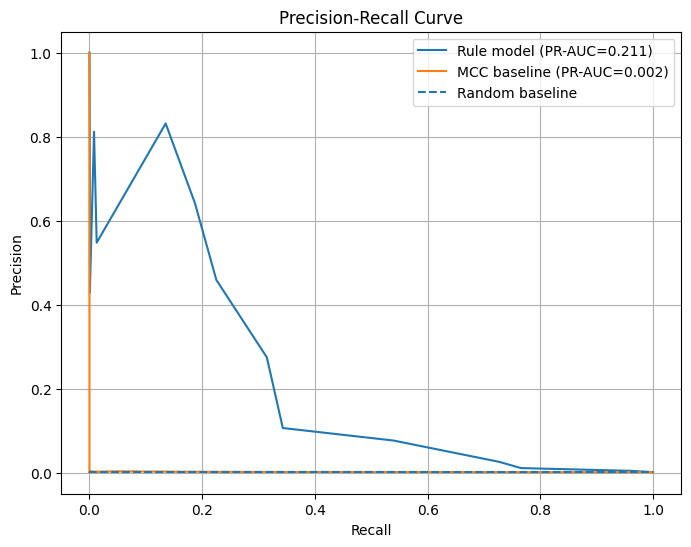

In [15]:
plt.figure(figsize=(8,6))

for col, name in [
    ("rule_score", "Rule model"),
    ("mcc_score", "MCC baseline")
]:

    precision, recall, _ = precision_recall_curve(
        results_no_ML["y_true"],
        results_no_ML[col]
    )

    pr_auc = average_precision_score(
        results_no_ML["y_true"],
        results_no_ML[col]
    )

    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

fraud_rate = results_no_ML["y_true"].mean()
plt.hlines(fraud_rate, 0, 1, linestyles="dashed", label="Random baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

Дадим бизнес-интерпретацию полученных моделей. Предположим, что каждый случай, когда модель помечает транзакцию как мошенническую, приводит к дополнительной проверке: сотрудники мониторингового отдела банка связываются с клиентом для подтверждения операции.

Модель типа «Всегда 0» пропускает все случаи мошенничества, но при этом не создаёт никакой дополнительной нагрузки на мониторинговый отдел.

Случайная модель создаёт небольшую нагрузку на отдел проверки, однако в данной выборке не выявляет ни одного реального случая мошенничества.

Модель на основе MCC и суммы транзакции на каждые 100 000 операций генерирует около 2065 сигналов, однако лишь примерно 6 из них оказываются реальными случаями мошенничества. При этом 116 мошеннических операций остаются незамеченными.

Эвристическая модель генерирует около 2465 сигналов, из которых 47 оказываются реальными мошенничествами, а 75 случаев остаются пропущенными. То есть эвристика находит много сигналов и за счёт этого обеспечивает высокий процент найденных случаев.

Наилучший результат среди рассмотренных baseline моделей показывает модель риск-скоринга на основе правил. Она генерирует всего 140 сигналов, при этом примерно каждый третий сигнал соответствует реальному мошенничеству. Несмотря на то, что 84 случаев мошенничества остаются незамеченными (около двух третей), для системы, основанной исключительно на правилах, это является достаточно высоким результатом.

Итоговые показатели модели: PR-AUC = 0.0.2105, Precision = 0.459, Recall = 0.2251.

В имеющейся документации указывалось, что минимально приемлемый уровень для работы системы составлял примерно Precision = 0.30 и Recall = 0.25. Полученные результаты соответствуют этим требованиям, что позволяет говорить о сопоставимом уровне эффективности с банковскими rule-based антифрод системами конца 1990-х — начала 2000-х годов.

Метрика PR-AUC в тот период практически не использовалась как стандартная метрика оценки, поэтому прямое историческое сравнение затруднено. Однако из открытых источников известно, что лучшие rule-based системы могли достигать значений Precision и Recall в диапазоне 0.30-0.40, но требовали постоянной корректировки и обновления правил экспертами.

Исходя из полученных результатов можно сделать несколько выводов.

В рамках условной бизнес-задачи данная rule-based система может рассматриваться как baseline, который должны превзойти модели машинного обучения.

Становится понятным, почему многие банки достаточно долго не внедряли ML-модели. Если модели машинного обучения давали лишь незначительное улучшение относительно экспертных систем, переход мог быть экономически неоправданным, учитывая необходимость модернизации инфраструктуры, тестирования, согласования с регуляторами и последующего сопровождения.

Для нашего проекта можно отметить, что используемые признаки содержат существенный предиктивный сигнал — иначе rule-based система не смогла бы показать столь высокий результат.




In [16]:
# Сохраним результаты для дальнейшего сравнения с ML-моделями
results_no_ML.to_parquet("baseline_no_ML_results.parquet", index=False)
# Очистка переменных из памяти
for var in [
    'data', 'schema', 'train', 'test', 'y_train', 'y_test', 'y_pred_zero', 'fraud_rate', 'y_pred_random',
    'mcc_channel_fraud_mean_amount', 'mcc_fraud_mean_amount', 'mcc_channel_mean_test', 'mcc_mean_fallback',
    'mean_amount_test', 'multiplier', 'y_pred_baseline_3', 'y_score_baseline_3', 'global_fraud_rate', 'mean_amount',
    'candidate_features', 'risky_values', 'signals', 'y_pred_heuristic', 'results_threshold', 'threshold', 'flagged',
    'flagged_rate', 'df_threshold', 'y_pred', 'y_score', 'df_mcc_threshold', 'mcc_mean_test', 'risk_score_train',
    'best_f1', 'best_threshold', 'pred', 'f1', 'risk_score_test', 'y_pred_prob', 'y_pred_rule', 'data_linear',
    'predictions_dict', 'df_business_100k', 'name', 'precision', 'recall', 'pr_auc','col', 'dtype_str', 'f', 
    'fraud_rate_by_value', 't', 'thresholds', 'top_values','var', 'results_no_ML'
]:
    if var in globals():
        del globals()[var]

import gc
gc.collect()

3688

## 4.2 Base-line модель на базе простой логистической регрессии

In [60]:
# Загружаем данные для линейной модели
data_linear = pd.read_parquet('data_linear.parquet')

with open('data_linear_schema.json', 'r', encoding='utf-8') as f:
    schema = json.load(f)

# сначала datetime
for col in schema['datetime_cols']:
    if col in data_linear.columns:
        data_linear[col] = pd.to_datetime(data_linear[col], errors='coerce')

# потом category
for col in schema['category_cols']:
    if col in data_linear.columns:
        data_linear[col] = data_linear[col].astype('category')

# потом остальные типы
for col, dtype_str in schema['dtypes'].items():
    if col not in data_linear.columns:
        continue
    
    if col in schema['datetime_cols'] or col in schema['category_cols']:
        continue
    
    try:
        if dtype_str == 'object':
            data_linear[col] = data_linear[col].astype('string')
        else:
            data_linear[col] = data_linear[col].astype(dtype_str)
    except Exception as e:
        print(f'Не удалось привести {col} к {dtype_str}: {e}')

print(data_linear.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7890638 entries, 0 to 7890637
Data columns (total 52 columns):
 #   Column                               Dtype   
---  ------                               -----   
 0   Amount                               float32 
 1   Use_Chip                             int8    
 2   Is_Online                            int8    
 3   Merchant_State                       category
 4   MCC                                  int16   
 5   Fraud                                int8    
 6   Gender                               int8    
 7   Is_Apartment                         int8    
 8   Total_Debt                           float32 
 9   FICO                                 int16   
 10  Num_Credit_Cards                     int8    
 11  Card_Brand                           category
 12  Card_Type                            category
 13  Has_Chip                             int8    
 14  Cards_Issued                         int8    
 15  Credit_Limit   

In [61]:
# Делаем MCC категориальным признаком
data_linear['MCC'] = data_linear['MCC'].astype('category')

In [62]:
# Разбиваем на train, validate и test по времени в пропорции 70/15/15
train, test = train_test_split(data_linear, test_size=0.3, shuffle=False)
validate, test = train_test_split(test, test_size=0.5, shuffle=False)

In [63]:
# Подготовка данных для линейной модели
# Задаём целевую переменную
target_col = 'Fraud'
# Список категориальных признаков для OneHotEncoder
cat_cols = [
    'Merchant_State',
    'Card_Brand',
    'Card_Type',
    'MCC'
]
# Список всех признаков кроме целевой переменной
feature_cols = [c for c in data_linear.columns if c != target_col]
# Список числовых признаков для StandardScaler
num_cols = [c for c in feature_cols if c not in cat_cols]

print('num_cols:', len(num_cols))
print('cat_cols:', len(cat_cols))

# Разделяем на X и y для train, validate и test
X_train = train[feature_cols]
X_validate = validate[feature_cols]
X_test = test[feature_cols]

y_train = train[target_col]
y_validate = validate[target_col]
y_test = test[target_col]

# Создаём ColumnTransformer для числовых и категориальных признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

# Применяем трансформацию к train, validate и test
X_train_prepared = preprocessor.fit_transform(X_train)
X_validate_prepared = preprocessor.transform(X_validate)
X_test_prepared = preprocessor.transform(X_test)

# Проверяем размеры подготовленных данных
print('X_train_prepared:', X_train_prepared.shape)
print('X_validate_prepared:', X_validate_prepared.shape)
print('X_test_prepared:', X_test_prepared.shape)


num_cols: 47
cat_cols: 4
X_train_prepared: (5523446, 340)
X_validate_prepared: (1183596, 340)
X_test_prepared: (1183596, 340)


In [21]:
fraud_distribution = pd.DataFrame({
    'dataset': ['train', 'validate', 'test'],
    'rows': [len(train), len(validate), len(test)],
    'fraud_count': [train[target_col].sum(), validate[target_col].sum(), test[target_col].sum()]
})

fraud_distribution['fraud_rate'] = fraud_distribution['fraud_count'] / fraud_distribution['rows']
fraud_distribution['fraud_percent'] = fraud_distribution['fraud_rate'] * 100

display(fraud_distribution)

for df_name, df_part in [('train', train), ('validate', validate), ('test', test)]:
    print(f'\n{df_name.upper()}')
    print(df_part[target_col].value_counts(dropna=False).sort_index())
    print(f'Fraud rate: {df_part[target_col].mean():.6f} ({df_part[target_col].mean() * 100:.4f}%)')

,dataset,rows,fraud_count,fraud_rate,fraud_percent
0,train,5523446,7804,0.001413,0.141289
1,validate,1183596,1745,0.001474,0.147432
2,test,1183596,1789,0.001511,0.15115



TRAIN
Fraud
0    5515642
1       7804
Name: count, dtype: int64
Fraud rate: 0.001413 (0.1413%)

VALIDATE
Fraud
0    1181851
1       1745
Name: count, dtype: int64
Fraud rate: 0.001474 (0.1474%)

TEST
Fraud
0    1181807
1       1789
Name: count, dtype: int64
Fraud rate: 0.001511 (0.1511%)


In [22]:
simple_logreg_model = LogisticRegression(random_state=42)
simple_logreg_model.fit(X_train_prepared, y_train)
# Предсказания на validate
y_validate_prob_simple_logreg = simple_logreg_model.predict_proba(X_validate_prepared)[:, 1]
y_validate_pred_simple_logreg = (y_validate_prob_simple_logreg >= 0.5).astype(int)
# Оцениваем на validate
add_result_prob('Простая логистическая регрессия(без подбора гиперпараметров) на валидации', y_validate, y_validate_prob_simple_logreg, threshold=0.5)
show_results()


,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674
4,Риск-скор на основе правил,0.2105,0.9346,0.9987,0.459,0.2251,0.3021
3,Эвристика на глаз,0.0081,0.6803,0.9751,0.0191,0.3849,0.0364
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017
0,Всегда 0,0.0012,0.5,0.9988,0,0,0


In [23]:
# Посмотрим на важность признаков в модели. 

# Получаем имена признаков после трансформации
feature_names = preprocessor.get_feature_names_out()

# Получаем коэффициенты логистической регрессии
coefficients = simple_logreg_model.coef_[0]

# Создаём таблицу признаков и коэффициентов
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Добавим абсолютное значение коэффициента
coef_df['abs_coef'] = coef_df['coefficient'].abs()

# Топ признаков увеличивающих вероятность fraud
top_fraud = coef_df.sort_values('coefficient', ascending=False).head(20)

# Топ признаков уменьшающих вероятность fraud
top_nonfraud = coef_df.sort_values('coefficient').head(20)

print("ТОП-20 признаков увеличивающих шанс мошенничества:")
display(top_fraud[['feature','coefficient']])

print("ТОП-20 признаков уменьшающих шанс мошенничества:")
display(top_nonfraud[['feature','coefficient']])

ТОП-20 признаков увеличивающих шанс мошенничества:


,feature,coefficient
274,cat__MCC_4829,5.65769
284,cat__MCC_5300,2.962935
285,cat__MCC_5310,2.700229
296,cat__MCC_5719,2.178143
2,num__Is_Online,1.631442
278,cat__MCC_5094,1.332312
298,cat__MCC_5732,1.231353
265,cat__MCC_4112,0.90445
305,cat__MCC_5912,0.831307
326,cat__MCC_7832,0.724877


ТОП-20 признаков уменьшающих шанс мошенничества:


,feature,coefficient
272,cat__MCC_4784,-8.095329
266,cat__MCC_4121,-3.672102
313,cat__MCC_6300,-3.507085
276,cat__MCC_4900,-2.749962
228,cat__Card_Type_Credit,-2.545496
275,cat__MCC_4899,-2.323659
229,cat__Card_Type_Debit,-2.124131
273,cat__MCC_4814,-2.057671
225,cat__Card_Brand_Discover,-1.605524
226,cat__Card_Brand_Mastercard,-1.593131


Мы видим, что в топ-признаки вошли "опасные" MCC и статус "он-лайн" платежа.

In [24]:
simple_logreg_model.intercept_

array([-6.25544126])

## 4.3 Усовершенствование моделей логистической регрессии

In [25]:
# Попробуем сделать таблицу менее разреженной. Уберем MCC признаки
cat_cols_no_mcc = [col for col in cat_cols if col != 'MCC']
preprocessor_no_mcc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_no_mcc)
    ],
    remainder='drop'
)
X_train_prepared_no_mcc = preprocessor_no_mcc.fit_transform(X_train)
X_validate_prepared_no_mcc = preprocessor_no_mcc.transform(X_validate)
X_test_prepared_no_mcc = preprocessor_no_mcc.transform(X_test)

# Строим модель
simple_logreg_model_no_mcc = LogisticRegression(random_state=42)
simple_logreg_model_no_mcc.fit(X_train_prepared_no_mcc, y_train)
# Предсказания на validate
y_validate_prob_simple_logreg_no_mcc = simple_logreg_model_no_mcc.predict_proba(X_validate_prepared_no_mcc)[:, 1]
y_validate_pred_simple_logreg_no_mcc = (y_validate_prob_simple_logreg_no_mcc >= 0.5).astype(int)
# Оцениваем на validate
add_result_prob('Простая логистическая регрессия (без MCC) на валидации', y_validate, y_validate_prob_simple_logreg_no_mcc, threshold=0.5)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674
4,Риск-скор на основе правил,0.2105,0.9346,0.9987,0.459,0.2251,0.3021
3,Эвристика на глаз,0.0081,0.6803,0.9751,0.0191,0.3849,0.0364
2,Рисковые суммы по MCC,0.0013,0.5154,0.9783,0.0031,0.0515,0.0058
1,Случайная,0.0012,0.5002,0.9975,0.0017,0.0018,0.0017
0,Всегда 0,0.0012,0.5,0.9988,0,0,0


Как видим, показатели изменились не существенно - определённыые категории продавцов действительно используются в мошенничестве чаще других, но модель явно видит более сильные сигналы от других признаков.

In [26]:
# Освободим память экмперимента.
for var in ['cat_cols_no_mcc', 'preprocessor_no_mcc', 'X_train_prepared_no_mcc', 'X_validate_prepared_no_mcc', 'X_test_prepared_no_mcc',
            'simple_logreg_model_no_mcc', 'y_validate_prob_simple_logreg_no_mcc', 'y_validate_pred_simple_logreg_no_mcc'
    ]:
    if var in globals():
        del globals()[var]

import gc
gc.collect()

115

Threshold: 0.10, Precision: 0.3717, Recall: 0.4367, F1: 0.4016, PR-AUC: 0.3918
Threshold: 0.15, Precision: 0.4495, Recall: 0.3954, F1: 0.4207, PR-AUC: 0.3918
Threshold: 0.20, Precision: 0.5155, Recall: 0.3628, F1: 0.4258, PR-AUC: 0.3918
Threshold: 0.25, Precision: 0.5662, Recall: 0.3307, F1: 0.4175, PR-AUC: 0.3918
Threshold: 0.30, Precision: 0.6107, Recall: 0.3129, F1: 0.4138, PR-AUC: 0.3918
Threshold: 0.35, Precision: 0.6464, Recall: 0.2923, F1: 0.4025, PR-AUC: 0.3918
Threshold: 0.40, Precision: 0.6657, Recall: 0.2751, F1: 0.3893, PR-AUC: 0.3918
Threshold: 0.45, Precision: 0.6965, Recall: 0.2630, F1: 0.3819, PR-AUC: 0.3918
Threshold: 0.50, Precision: 0.7171, Recall: 0.2470, F1: 0.3674, PR-AUC: 0.3918
Threshold: 0.55, Precision: 0.7561, Recall: 0.2327, F1: 0.3558, PR-AUC: 0.3918
Threshold: 0.60, Precision: 0.7796, Recall: 0.2189, F1: 0.3418, PR-AUC: 0.3918
Threshold: 0.65, Precision: 0.8000, Recall: 0.2017, F1: 0.3222, PR-AUC: 0.3918
Threshold: 0.70, Precision: 0.8308, Recall: 0.1885, 

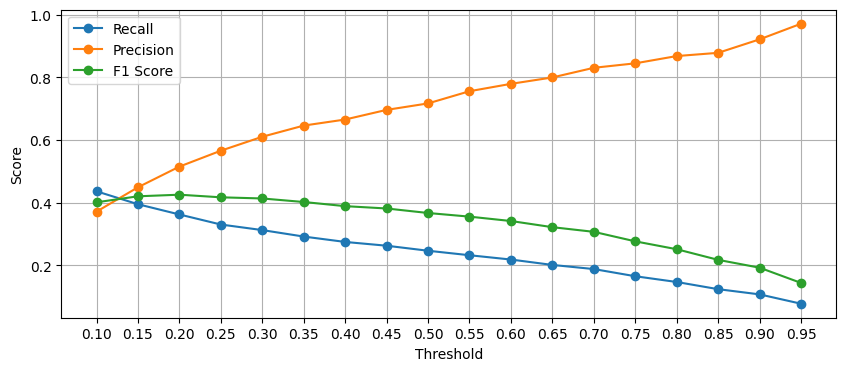

In [27]:
# Подберем оптимальный порог для логистической регрессии на validate
thresholds = np.arange(0.1, 1, 0.05)
y_validate_proba = simple_logreg_model.predict_proba(X_validate_prepared)[:, 1]
recall_scores, precision_scores, f1_scores = [], [], []
for threshold in thresholds:
    y_validate_pred = (y_validate_proba >= threshold).astype(int)
    recall_scores.append(recall_score(y_validate, y_validate_pred))
    precision_scores.append(precision_score(y_validate, y_validate_pred, zero_division=0))
    f1_scores.append(f1_score(y_validate, y_validate_pred, zero_division=0))
    auc_pr = average_precision_score(y_validate, y_validate_proba) # PR-AUC не зависит от порога, так что можно считать один раз, но для наглядности я оставил внутри цикла
    print(f"Threshold: {threshold:.2f}, Precision: {precision_scores[-1]:.4f}, Recall: {recall_scores[-1]:.4f}, F1: {f1_scores[-1]:.4f}, PR-AUC: {auc_pr:.4f}")
    
# Визуализируем Precision-Recall кривую
fix, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, recall_scores, label='Recall', marker='o')
ax.plot(thresholds, precision_scores, label='Precision', marker='o')
ax.plot(thresholds, f1_scores, label='F1 Score', marker='o')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_xticks(thresholds)
ax.grid()
ax.legend()


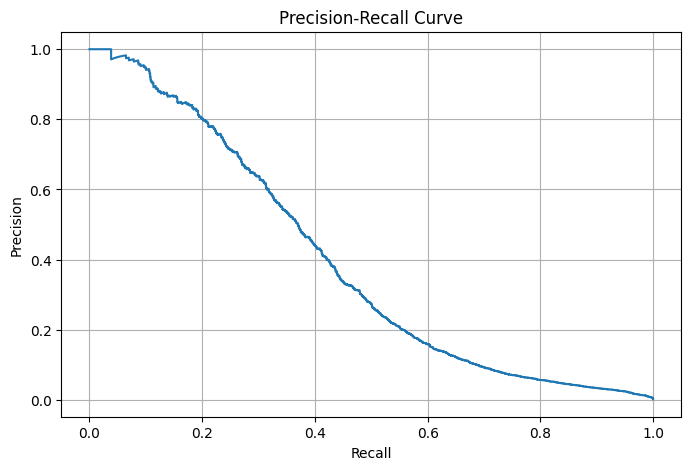

In [28]:
# Построим Precision-Recall кривую для лучшего порога
precision, recall, thresholds = precision_recall_curve(
    y_validate,
    y_validate_proba
)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [ ]:
# Перез запуском GridSearchCV и более сложных моделей освободим память от данных для линейной модели, которые нам больше не нужны.
del data_linear, X_train, X_validate, X_test
gc.collect()

In [36]:
# Подберем гиперпараметры для логистической регрессии с помощью GridSearchCV и TimeSeriesSplit
# TimeSeriesSplit сохраняет порядок строк и не перемешивает данные
if True: # для простого отключения кода при необходимости
    tscv = TimeSeriesSplit(n_splits=3)

    param_grid = {
        'C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 15.0],
        'class_weight': [None, 'balanced']
    }

    base_model = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        max_iter=300,
        random_state=42
    )

    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='average_precision',
        cv=tscv,
        n_jobs=4,
        pre_dispatch=1,
        verbose=10,
        refit=True,
        return_train_score=True
    )

    grid.fit(X_train_prepared, y_train)

    print("Лучшие гиперпараметры:", grid.best_params_)
    print("Лучший PR-AUC:", grid.best_score_)

Fitting 3 folds for each of 14 candidates, totalling 42 fits
Лучшие гиперпараметры: {'C': 10.0, 'class_weight': None}
Лучший PR-AUC: 0.4358279125831772


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Лучшие гиперпараметры: {'C': 10.0, 'class_weight': None}
Лучший PR-AUC: 0.4358279125831772

In [31]:
if True: # Продолжение кода прошлой ячейки
    best_model = grid.best_estimator_

    y_validate_proba = best_model.predict_proba(X_validate_prepared)[:,1]

    print(
    "Validate PR-AUC:",
    average_precision_score(y_validate, y_validate_proba)
    )

Validate PR-AUC: 0.38475604251498585


In [64]:
# Переподберем порог для лучшей модели на validate
best_C = 10
final_model_log_reg = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=300,
    random_state=42,
    C=best_C
)
final_model_log_reg.fit(X_train_prepared, y_train)
thresholds = np.arange(0.01, 0.99, 0.01)

results_threshold = []

y_validate_proba = final_model_log_reg.predict_proba(X_validate_prepared)[:,1]

for t in thresholds:

    y_pred = (y_validate_proba >= t).astype(int)

    precision = precision_score(y_validate, y_pred, zero_division=0)
    recall = recall_score(y_validate, y_pred, zero_division=0)
    f1 = f1_score(y_validate, y_pred, zero_division=0)

    results_threshold.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

thr_df = pd.DataFrame(results_threshold)
thr_df.sort_values("f1", ascending=False).head(20)

,threshold,precision,recall,f1
21,0.22,0.529672,0.342693,0.416145
19,0.2,0.509136,0.351289,0.415734
18,0.19,0.49642,0.357593,0.415723
20,0.21,0.518868,0.346705,0.415665
15,0.16,0.461754,0.377077,0.415142
16,0.17,0.472182,0.369628,0.414658
22,0.23,0.537409,0.337536,0.414643
14,0.15,0.449664,0.383954,0.414219
17,0.18,0.4835,0.361032,0.413386
12,0.13,0.424077,0.401719,0.412596


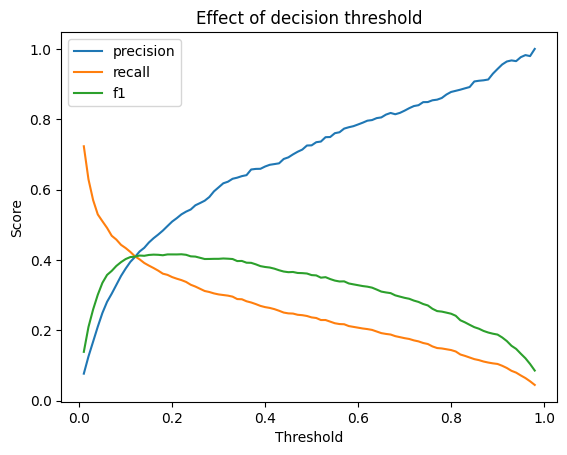

In [38]:
plt.plot(thr_df["threshold"], thr_df["precision"], label="precision")
plt.plot(thr_df["threshold"], thr_df["recall"], label="recall")
plt.plot(thr_df["threshold"], thr_df["f1"], label="f1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Effect of decision threshold")
plt.show()

In [65]:
# Обучим модель с лучшими гиперпараметрами и оптимальным порогом на train и validate, а затем оценим на test
final_model_log_reg_val = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=300,
    random_state=42,
    C=10
)
final_model_log_reg_val.fit(X_train_prepared, y_train)
y_validate_proba_val = final_model_log_reg_val.predict_proba(X_validate_prepared)[:, 1]
add_result_prob(
    'Логистическая регрессия (с подобранными гиперпараметрами) на валидации',
    y_validate,
    y_validate_proba_val,
    threshold=0.2
)

# Теперь оцениваем на test
y_test_proba = final_model_log_reg_val.predict_proba(X_test_prepared)[:, 1]
add_result_prob(
    'Логистическая регрессия (с подобранными гиперпараметрами) на тесте',
    y_test,
    y_test_proba,
    threshold=0.2
)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
14,Логистическая регрессия (с PCA + OHE) на валидации,0.4918,0.9977,0.9946,0.2026,0.8991,0.3306
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674
15,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.3848,0.9862,0.9985,0.5091,0.3513,0.4157
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.3848,0.9862,0.9985,0.5091,0.3513,0.4157


Мы видим, что результаты логистической регрессии с подбором гиперпараметров и без него меняются не существенно. Очевидно, что мы находимся на пределе возможностей простой логистической регрессии. Тем не менее, мы попробуем провести ещё несколько экспериментов. 

In [39]:
# Сохраняем топ-20 признаков по коэффициентам логрег в JSON,
# чтобы ноутбук 5 (Tree models) мог загрузить их без повторного обучения.

_num_feature_names = num_cols
_cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
_all_feature_names = _num_feature_names + _cat_feature_names

_coefs = final_model_log_reg_val.coef_[0]
_coef_df = pd.DataFrame({
    'feature': _all_feature_names,
    'coef': _coefs,
    'abs_coef': np.abs(_coefs)
})

def _get_base_feature(name):
    for cat in cat_cols:
        if name.startswith(cat + '_'):
            return 'cat_' + cat
    return name

_coef_df['base_feature'] = _coef_df['feature'].apply(_get_base_feature)

_cat_mask = _coef_df['base_feature'].str.startswith('cat_')
_combined = pd.concat([
    _coef_df[~_cat_mask],
    _coef_df[_cat_mask].groupby('base_feature', as_index=False).apply(
        lambda g: g.loc[g['abs_coef'].idxmax()]
    ).reset_index(drop=True)
], ignore_index=True).sort_values('abs_coef', ascending=False)

_important = _combined['base_feature'].str.replace('cat_', '', regex=False).tolist()
_important = [f for f in _important if f not in ['dow_cos', 'dow_sin', 'hour_cos', 'hour_sin']]
_top20 = _important[:20]

with open('logreg_top_features.json', 'w', encoding='utf-8') as _f:
    json.dump({'top20': _top20, 'all_ranked': _important}, _f, ensure_ascii=False, indent=2)

print("Топ-20 признаков по логистической регрессии сохранены → logreg_top_features.json")
print(_top20)

Топ-20 признаков по логистической регрессии сохранены → logreg_top_features.json
['MCC', 'Card_Type', 'Card_Brand', 'Is_Online', 'amount_round_10', 'time_since_prev_txn_user_min', 'Num_Credit_Cards', 'Merchant_State', 'Use_Chip', 'state_changed_1d', 'first_user_payment_to_this_merchant', 'prev_not_foreign_card', 'txn_gap_bin', 'amount_log', 'is_foreign_offline', 'Credit_Limit', 'Has_Chip', 'Error_Bad_PIN', 'is_business_hours', 'merchant_velocity_ratio_log']


C:\Users\dmytr\AppData\Local\Temp\ipykernel_12344\982569942.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _coef_df[_cat_mask].groupby('base_feature', as_index=False).apply(


In [42]:
# Финальное обучение на train + validate, тестирование на test

target_col = 'Fraud'

cat_cols = [
    'Merchant_State',
    'Card_Brand',
    'Card_Type',
    'MCC'
]

feature_cols = [c for c in data_linear.columns if c != target_col]
num_cols = [c for c in feature_cols if c not in cat_cols]

print('num_cols:', len(num_cols))
print('cat_cols:', len(cat_cols))

# Объединяем train и validate
X_train_final = pd.concat([X_train, X_validate], axis=0)
y_train_final = pd.concat([y_train, y_validate], axis=0)

# Используем уже существующий test
X_test_final = X_test.copy()
y_test_final = y_test.copy()

# Заново обучаем preprocessing на train+validate
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

X_train_final_prepared = preprocessor.fit_transform(X_train_final)
X_test_final_prepared = preprocessor.transform(X_test_final)

print('X_train_final_prepared:', X_train_final_prepared.shape)
print('X_test_final_prepared:', X_test_final_prepared.shape)

# Для референса обучим baseline-модель
simple_logreg_model_train_validate = LogisticRegression(random_state=42)
simple_logreg_model_train_validate.fit(X_train_final_prepared, y_train_final)

y_test_prob_simple_logreg = simple_logreg_model_train_validate.predict_proba(X_test_final_prepared)[:, 1]

add_result_prob(
    'Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test',
    y_test_final,
    y_test_prob_simple_logreg,
    threshold=0.5
)

# Финальная tuned-модель
best_C = 10
best_threshold = 0.20

final_model_log_reg = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=300,
    random_state=42,
    C=best_C
)

final_model_log_reg.fit(X_train_final_prepared, y_train_final)

y_test_proba = final_model_log_reg.predict_proba(X_test_final_prepared)[:, 1]

add_result_prob(
    'Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test',
    y_test_final,
    y_test_proba,
    threshold=best_threshold
)

show_results()

num_cols: 47
cat_cols: 4
X_train_final_prepared: (6707042, 353)
X_test_final_prepared: (1183596, 353)


,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.3848,0.9862,0.9985,0.5091,0.3513,0.4157
8,Логистическая регрессия (с подобранными гиперпараметрами) на тесте,0.3823,0.9844,0.9985,0.5222,0.3549,0.4226
4,Риск-скор на основе правил,0.2105,0.9346,0.9987,0.459,0.2251,0.3021
3,Эвристика на глаз,0.0081,0.6803,0.9751,0.0191,0.3849,0.0364


На данный момент мы можем показать, что ML однозначно превосходит любые системы, основанные на правилах. Базовая модель без подбора гиперпараметров уже существенно превосходит все не-ML модели.
Результат без подбора гиперпараметров оказался лучше, поскольку базовая логистическая регрессия уже адекватно захватывает устойчивый сигнал в данных, тогда как тюнинг оптимизировался под конкретный валидационный период с чуть иным распределением мошенничества, что привело к частичной переадаптации к его особенностям и ухудшению обобщающей способности на тесте; при этом из-за относительной простоты модели влияние гиперпараметров ограничено и чаще смещает баланс precision/recall, чем реально улучшает качество ранжирования, поэтому в условиях временного сдвига данных более “грубая”, но стабильная конфигурация без тюнинга оказывается более надежной.

## 4.4 Логистическая регрессия на полиномиальных признаках

In [45]:
# Для модели на полиномиальных признаках может понадобится много памяти - очистим память от всех переменных. 
# Все они занимают значительный объём ОЗУ, лучше будем по мере необходимости считывать их заново.
# Сохраняем только result т.к. в ней наша табличка для сравнения.
for var in [
    "GridSearchCV", "TimeSeriesSplit", "X_test", "X_test_final", "X_test_final_prepared", "X_test_prepared",
    "X_train", "X_train_final", "X_train_final_prepared", "X_train_prepared", "X_validate", "X_validate_prepared", "auc_pr", "ax",
    "best_C", "best_threshold", "cat_cols", "coef_df", "coefficients", "col", "data_linear", "dtype_str", "f", "f1", "f1_scores",
    "feature_cols", "feature_names", "final_model_log_reg", "final_model_log_reg_val", "fit_start", "fit_time", "fix", "i", "model",
    "num_cols", "param_grid", "params", "pr_auc", "precision", "precision_scores", "pred_start", "pred_time", "preprocessor",
    "recall", "recall_scores", "results_df", "results_logreg_param_search", "results_threshold", "roc_auc", "schema",
    "simple_logreg_model", "simple_logreg_model_train_validate", "start_time", "t", "target_col", "test", "thr_df", "threshold",
    "thresholds", "top_fraud", "top_nonfraud", "total_time", "train", "validate", "var", "y_pred", "y_test", "y_test_final",
    "y_test_prob_simple_logreg", "y_test_proba", "y_train", "y_train_final", "y_val_pred", "y_val_proba", "y_validate",
    "y_validate_pred", "y_validate_pred_simple_logreg", "y_validate_prob_simple_logreg", "y_validate_proba", "y_validate_proba_val", 
    'data_linear', 'X_train', 'X_validate', 'X_test'
]:
    if var in locals():
        del locals()[var]
    elif var in globals():
        del globals()[var]
        
gc.collect()
# На моём ПК освободилось более 15гб ОЗУ

0

Нам необходимо определить предел возможностей линейных моделей. Попробуем создать модель на полиномиальных признаках и посмотреть, даёт ли это улучшение модели. 

In [46]:
# Загружаем данные для линейной модели
data_linear = pd.read_parquet('data_linear.parquet')

with open('data_linear_schema.json', 'r', encoding='utf-8') as f:
    schema = json.load(f)

# сначала datetime
for col in schema['datetime_cols']:
    if col in data_linear.columns:
        data_linear[col] = pd.to_datetime(data_linear[col], errors='coerce')

# потом category
for col in schema['category_cols']:
    if col in data_linear.columns:
        data_linear[col] = data_linear[col].astype('category')

# потом остальные типы
for col, dtype_str in schema['dtypes'].items():
    if col not in data_linear.columns:
        continue
    
    if col in schema['datetime_cols'] or col in schema['category_cols']:
        continue
    
    try:
        if dtype_str == 'object':
            data_linear[col] = data_linear[col].astype('string')
        else:
            data_linear[col] = data_linear[col].astype(dtype_str)
    except Exception as e:
        print(f'Не удалось привести {col} к {dtype_str}: {e}')

# Делаем MCC категориальным признаком
data_linear['MCC'] = data_linear['MCC'].astype('category')
# Разбиваем на train, validate и test по времени в пропорции 70/15/15
train, test = train_test_split(data_linear, test_size=0.3, shuffle=False)
validate, test = train_test_split(test, test_size=0.5, shuffle=False)

In [47]:
train.tail()

,Amount,Use_Chip,Is_Online,Merchant_State,MCC,Fraud,Gender,Is_Apartment,Total_Debt,FICO,Num_Credit_Cards,Card_Brand,Card_Type,Has_Chip,Cards_Issued,Credit_Limit,txn_day,account_age_months,Amount_to_Income,Error_Bad_CVV,Error_Bad_Card_Number,Error_Bad_Expiration,Error_Bad_PIN,Error_Bad_Zipcode,Error_Insufficient_Balance,Error_Technical_Glitch,user_age,is_night,is_business_hours,amount_log,amount_round_10,time_since_prev_txn_card_min,time_since_prev_txn_user_min,txn_gap_bin,first_user_payment_to_this_merchant,txn_count_5m_card,txn_count_1h_card,txn_count_5m_user,txn_count_1h_user,state_changed_1d,errors_prev_1h,merchant_txn_count_1h,hour_sin,hour_cos,dow_sin,dow_cos,merchant_velocity_ratio_log,card_burst_5m,merchant_fraud_rate,state_fraud_rate,prev_not_foreign_card,is_foreign_offline
5523441,32.869999,0,1,NaN,4784,0,0,0,59605,775,3,Mastercard,Debit,1,1,19465,23,245,0.011917,0,0,0,0,0,0,0,48,0,1,3.52253,0,198,58,6,0,1,1,1,2,1,0,0,0.258819,-0.965926,0.974928,-0.222521,-0.693147,0,0,0,1,0
5523442,78.169998,1,0,CA,3387,0,1,0,78833,712,3,Visa,Debit,1,2,2365,23,138,0.022635,0,0,0,0,0,0,0,32,0,1,4.371597,0,1311,149,6,0,1,1,1,1,0,0,0,0.258819,-0.965926,0.974928,-0.222521,0,0,0.008031,0.00034,1,0
5523443,97,1,0,TX,5499,0,0,0,317964,540,1,Visa,Debit,1,2,6076,23,167,0.007217,0,0,0,0,0,0,0,35,0,1,4.584968,0,206,206,6,0,1,1,1,2,0,0,0,0.258819,-0.965926,0.974928,-0.222521,0,0,0.000082,0.000205,1,0
5523444,40.75,0,0,GA,7538,0,1,0,75730,753,4,Mastercard,Debit,1,1,21895,23,109,0.013196,0,0,0,0,0,0,0,44,0,1,3.731699,0,195,195,6,0,1,1,1,1,0,0,0,0.258819,-0.965926,0.974928,-0.222521,0,0,0.000011,0.000185,1,0
5523445,7.02,1,0,CA,5411,0,1,0,15336,743,5,Mastercard,Debit,1,1,27243,23,77,0.002721,0,0,0,0,0,0,0,65,0,1,2.081939,0,1709,277,7,0,1,1,1,1,0,0,0,0.258819,-0.965926,0.974928,-0.222521,0,0,0,0.00034,0,0


In [48]:
# Целевая переменная
target_col = 'Fraud'

# Категориальные признаки
cat_cols = [
    'Merchant_State',
    'Card_Brand',
    'Card_Type',
    'MCC'
]

# Числовые признаки, для которых строим полиномиальные признаки
poly_cols = [
    'Amount',
    'amount_log',
    'time_since_prev_txn_card_min',
    'time_since_prev_txn_user_min',
    'merchant_velocity_ratio_log',
    'merchant_fraud_rate',
    'state_fraud_rate'
]

# Все признаки кроме target
feature_cols = [c for c in data_linear.columns if c != target_col]

# Оставшиеся числовые признаки без полиномиального расширения
num_cols = [c for c in feature_cols if c not in cat_cols and c not in poly_cols]

print('cat_cols:', len(cat_cols))
print('poly_cols:', len(poly_cols))
print('num_cols:', len(num_cols))

# X / y
X_train = train[feature_cols]
X_validate = validate[feature_cols]
X_test = test[feature_cols]

y_train = train[target_col]
y_validate = validate[target_col]
y_test = test[target_col]

# Pipeline для полиномиальных признаков
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

# Pipeline для обычных числовых
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Общий препроцессинг
preprocessor_poly_selected = ColumnTransformer(
    transformers=[
        ('poly_num', poly_pipeline, poly_cols),
        ('num', num_pipeline, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

# Преобразуем данные
X_train_prepared_poly_selected = preprocessor_poly_selected.fit_transform(X_train)
X_validate_prepared_poly_selected = preprocessor_poly_selected.transform(X_validate)
X_test_prepared_poly_selected = preprocessor_poly_selected.transform(X_test)

print('X_train_prepared_poly_selected:', X_train_prepared_poly_selected.shape)
print('X_validate_prepared_poly_selected:', X_validate_prepared_poly_selected.shape)
print('X_test_prepared_poly_selected:', X_test_prepared_poly_selected.shape)

# Простая логистическая регрессия без подбора параметров
poly_selected_logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

poly_selected_logreg.fit(X_train_prepared_poly_selected, y_train)

# Предсказания на validate
y_validate_proba_poly_selected = poly_selected_logreg.predict_proba(
    X_validate_prepared_poly_selected
)[:, 1]

y_validate_pred_poly_selected = (y_validate_proba_poly_selected >= 0.5).astype(int)

    
# Метрики
print('Результаты модели с полиномиальными признаками для отдельных стобцов на validate:')
print('PR-AUC:', average_precision_score(y_validate, y_validate_proba_poly_selected))
print('ROC-AUC:', roc_auc_score(y_validate, y_validate_proba_poly_selected))
print('Precision@0.5:', precision_score(y_validate, y_validate_pred_poly_selected, zero_division=0))
print('Recall@0.5:', recall_score(y_validate, y_validate_pred_poly_selected, zero_division=0))
print('F1@0.5:', f1_score(y_validate, y_validate_pred_poly_selected, zero_division=0))

cat_cols: 4
poly_cols: 7
num_cols: 40
X_train_prepared_poly_selected: (5523446, 368)
X_validate_prepared_poly_selected: (1183596, 368)
X_test_prepared_poly_selected: (1183596, 368)


c:\Users\dmytr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Результаты модели с полиномиальными признаками для отдельных стобцов на validate:
PR-AUC: 0.5391121777148697
ROC-AUC: 0.990631928912036
Precision@0.5: 0.6528365791701948
Recall@0.5: 0.44183381088825213
F1@0.5: 0.5269993164730007


In [49]:
# Побираем порог для лучшей модели на validate
thresholds = np.arange(0.01, 0.99, 0.01)
results_threshold_poly_selected = []
for t in thresholds:

    y_pred = (y_validate_proba_poly_selected >= t).astype(int)

    precision = precision_score(y_validate, y_pred, zero_division=0)
    recall = recall_score(y_validate, y_pred, zero_division=0)
    f1 = f1_score(y_validate, y_pred, zero_division=0)

    results_threshold_poly_selected.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })
thr_poly_selected_df = pd.DataFrame(results_threshold_poly_selected)
thr_poly_selected_df.sort_values("f1", ascending=False).head(20)


,threshold,precision,recall,f1
48,0.49,0.650168,0.444126,0.527749
47,0.48,0.644096,0.446991,0.52774
49,0.5,0.652837,0.441834,0.526999
45,0.46,0.6312,0.452149,0.526878
44,0.45,0.625888,0.454441,0.52656
43,0.44,0.6189,0.45788,0.52635
42,0.43,0.612167,0.461318,0.526144
52,0.53,0.673524,0.431519,0.526022
50,0.51,0.658621,0.437822,0.52599
40,0.41,0.598829,0.468768,0.525876


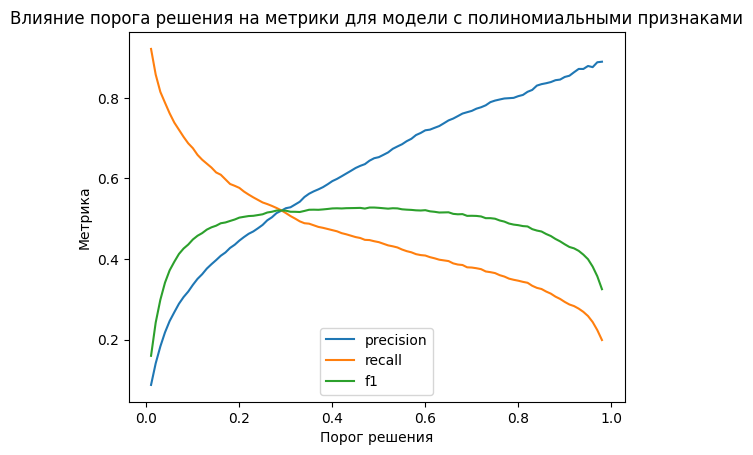

In [50]:
# График зависимости метрик от порога для модели с полиномиальными признаками
plt.plot(thr_poly_selected_df["threshold"], thr_poly_selected_df["precision"], label="precision")
plt.plot(thr_poly_selected_df["threshold"], thr_poly_selected_df["recall"], label="recall")
plt.plot(thr_poly_selected_df["threshold"], thr_poly_selected_df["f1"], label="f1")
plt.xlabel("Порог решения")
plt.ylabel("Метрика") 
plt.legend()
plt.title("Влияние порога решения на метрики для модели с полиномиальными признаками")
plt.show()

In [51]:
# Смотрим результат
y_validate_proba = poly_selected_logreg.predict_proba(X_validate_prepared_poly_selected)[:, 1]

add_result_prob(
    'Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации',
    y_validate,
    y_validate_proba,
    threshold=0.4
)

show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.3848,0.9862,0.9985,0.5091,0.3513,0.4157
8,Логистическая регрессия (с подобранными гиперпараметрами) на тесте,0.3823,0.9844,0.9985,0.5222,0.3549,0.4226
4,Риск-скор на основе правил,0.2105,0.9346,0.9987,0.459,0.2251,0.3021


Как видим, полиномиальные признаки не помогли улучшить модель. Т.е. полиномиальные взаимодействия оказались бесполезны для точности предсказания. Скорее всего это связано тем, что мы и так создали много хороших признаков взаимодействия, а полиномиальные признаки только внесли шум. Мы не будем проверять её на тесте т.к. при очевидноом падении результатов на валидации нет смысла проводиить тест.

In [52]:
# Снова чистим память перед последним этапом
for var in [
    "data_linear", "schema", "target_col", "cat_cols", "feature_cols", "num_cols",
    "X_train", "X_validate", "X_test", "y_train", "y_validate", "y_test", "poly_pipeline", "num_pipeline",
    "preprocessor_poly_selected", "X_train_prepared_poly_selected", "X_validate_prepared_poly_selected", "X_test_prepared_poly_selected",
    "poly_selected_logreg", "y_validate_proba_poly_selected", "y_validate_pred_poly_selected", "thresholds",
    "results_threshold_poly_selected", "thr_poly_selected_df", "y_validate_proba", "y_pred"
]:
    if var in locals():
        del locals()[var]
    elif var in globals():
        del globals()[var]
import gc
gc.collect()

3406

## 4.5 Уменьшение размерности в антифрод-анализе

На финальном этапе работы с линейными моделями мы попробуем проверить, помогает ли уменьшение размерности лучше предсказывать мошеннические транзакции.
Теория состоит в том, что если оставшиеся признаки будут объяснять 95% дисперсии и при этом их будет существенно меньше - качество модели не ухудшится.

In [53]:
# Целевая переменная
target_col = 'Fraud'

# Категориальные признаки
cat_cols = [
    'Merchant_State',
    'Card_Brand',
    'Card_Type',
    'MCC'
]

# Все признаки кроме target
feature_cols = [c for c in train.columns if c != target_col]

# Числовые признаки
num_cols = [c for c in feature_cols if c not in cat_cols]

print('num_cols:', len(num_cols))
print('cat_cols:', len(cat_cols))

# Разделяем на X и y для train, validate и test
X_train = train[feature_cols]
X_validate = validate[feature_cols]
X_test = test[feature_cols]

y_train = train[target_col]
y_validate = validate[target_col]
y_test = test[target_col]


# Пайплайн для числовых признаков
num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)) # сохраняем 95% дисперсии
])

# Пайплайн для категориальных признаков
cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Общий препроцессор
preprocessor_pca_ohe = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ],
    remainder='drop'
)

# fit только на train
X_train_pca_ohe = preprocessor_pca_ohe.fit_transform(X_train, y_train)

# transform на validate и test
X_validate_pca_ohe = preprocessor_pca_ohe.transform(X_validate)
X_test_pca_ohe = preprocessor_pca_ohe.transform(X_test)

print("Изначальные признаки:", X_train.shape[1])
print("Признаки после PCA + OHE:", X_train_pca_ohe.shape[1])

# Информация по PCA
pca_model = preprocessor_pca_ohe.named_transformers_['num'].named_steps['pca']
print("Количество PCA-компонент:", pca_model.n_components_)
print("Суммарная объяснённая дисперсия:", pca_model.explained_variance_ratio_.sum())

# Обучаем логистическую регрессию на данных после PCA и OHE

logreg_pca_ohe = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

logreg_pca_ohe.fit(X_train_pca_ohe, y_train)

# Оценка на validate

y_validate_proba = logreg_pca_ohe.predict_proba(X_validate_pca_ohe)[:, 1]
y_validate_pred = logreg_pca_ohe.predict(X_validate_pca_ohe)

validate_metrics = {
    'PR-AUC': average_precision_score(y_validate, y_validate_proba),
    'ROC-AUC': roc_auc_score(y_validate, y_validate_proba),
    'Accuracy': accuracy_score(y_validate, y_validate_pred),
    'Precision': precision_score(y_validate, y_validate_pred, zero_division=0),
    'Recall': recall_score(y_validate, y_validate_pred, zero_division=0),
    'F1': f1_score(y_validate, y_validate_pred, zero_division=0)
}

print('\nМетрики на validate:')
for metric_name, metric_value in validate_metrics.items():
    print(f'{metric_name}: {metric_value:.4f}')

# Подбираем оптимальный порог для модели с PCA + OHE
thresholds = np.arange(0.01, 0.99, 0.01)
results_threshold_pca_ohe = []
for t in thresholds:
    y_pred = (y_validate_proba >= t).astype(int)
    precision = precision_score(y_validate, y_pred, zero_division=0)
    recall = recall_score(y_validate, y_pred, zero_division=0)
    f1 = f1_score(y_validate, y_pred, zero_division=0)
    results_threshold_pca_ohe.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })
    
thr_pca_ohe_df = pd.DataFrame(results_threshold_pca_ohe)
thr_pca_ohe_df.sort_values("f1", ascending=False).head(20)



num_cols: 47
cat_cols: 4
Изначальные признаки: 51
Признаки после PCA + OHE: 334
Количество PCA-компонент: 41
Суммарная объяснённая дисперсия: 0.958723588847251

Метрики на validate:
PR-AUC: 0.4918
ROC-AUC: 0.9977
Accuracy: 0.9670
Precision: 0.0427
Recall: 0.9960
F1: 0.0818


,threshold,precision,recall,f1
97,0.98,0.202556,0.89914,0.330629
96,0.97,0.175729,0.918625,0.295022
95,0.96,0.159303,0.938109,0.272357
94,0.95,0.14676,0.951289,0.254289
93,0.94,0.135541,0.95702,0.237452
92,0.93,0.126905,0.963897,0.224282
91,0.92,0.118871,0.965616,0.211683
90,0.91,0.11226,0.970774,0.201247
89,0.9,0.105908,0.970774,0.190981
88,0.89,0.100819,0.973066,0.182708


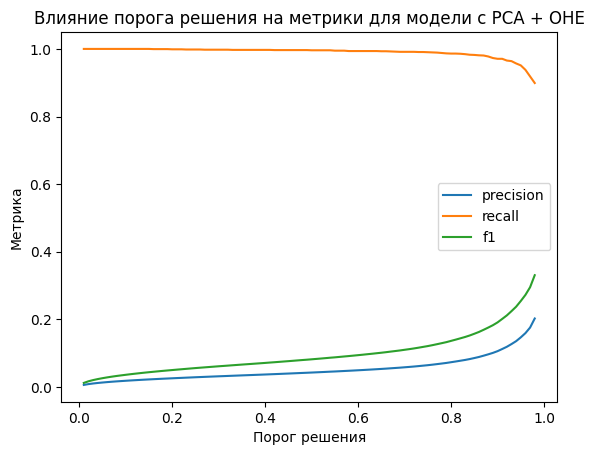

In [54]:
# Строми график завимисоти метрик от порога для модели с PCA + OHE
plt.plot(thr_pca_ohe_df["threshold"], thr_pca_ohe_df["precision"], label="precision")
plt.plot(thr_pca_ohe_df["threshold"], thr_pca_ohe_df["recall"], label="recall")
plt.plot(thr_pca_ohe_df["threshold"], thr_pca_ohe_df["f1"], label="f1")
plt.xlabel("Порог решения")
plt.ylabel("Метрика")
plt.legend()
plt.title("Влияние порога решения на метрики для модели с PCA + OHE")
plt.show()


Как видим, оптимальной точки графики вообще не имеют. Возьмем максимальный f1, но уже очевидно, что экмперимент не удачный.

In [55]:
# Делаем предсказание на валидации для референса
add_result_prob(
    'Логистическая регрессия (с PCA + OHE) на валидации',
    y_validate,
    y_validate_proba,
    threshold=0.98
)
show_results()

,Model,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,F1
9,Логистическая регрессия (без подбора гиперпараметров) на тесте,0.5957,0.9963,0.9989,0.7781,0.398,0.5266
11,"Логистическая регрессия (без подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5957,0.9963,0.9989,0.7781,0.398,0.5266
12,"Логистическая регрессия (после подбора гиперпараметров) обучена на train+validate, тестирование на test",0.5813,0.9958,0.9987,0.5781,0.5254,0.5505
10,Логистическая регрессия (после подбора гиперпараметров) на тесте,0.5813,0.9958,0.9988,0.6226,0.4925,0.5499
13,Логистическая регрессия (с полиномиальными признаками для отдельных столбцов) на валидации,0.5391,0.9906,0.9987,0.5934,0.4716,0.5255
14,Логистическая регрессия (с PCA + OHE) на валидации,0.4918,0.9977,0.9946,0.2026,0.8991,0.3306
6,Простая логистическая регрессия (без MCC) на валидации,0.3955,0.9788,0.9988,0.781,0.2453,0.3733
5,Простая логистическая регрессия(без подбора гиперпараметров) на валидации,0.3918,0.9865,0.9987,0.7171,0.247,0.3674
7,Логистическая регрессия (с подобранными гиперпараметрами) на валидации,0.3848,0.9862,0.9985,0.5091,0.3513,0.4157
8,Логистическая регрессия (с подобранными гиперпараметрами) на тесте,0.3823,0.9844,0.9985,0.5222,0.3549,0.4226


Вывод - методы уменьшения размерности приводят к существенной потере предсказательной способности модели. Это вызвано тем, что в подобных моделях множество признаков даёт достаточно слабые сигналы, без которых модель не может эффективно работать. Более того, мы сократили всего 10 признаков, что не является существенным. Таким образом в уменьшении размерности для данного датасета нет смысла.

In [56]:
# Сохраним список результатов
with open('results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

In [66]:
# Пиклилизуем финальную модель обученную на train для использования в будущем (стэкинг)
import pickle
with open('final_model_log_reg.pkl', 'wb') as output:
    pickle.dump(final_model_log_reg, output)

## 4.6 Выводы

Мы проанализировали базовые модели не основанные на машинном обучении и относительно простые модели машинного обучения основанные на линейных моделях.

Для референса мы создали несколько "не модельных" системы - полный отказ от поиска мошенничества, случайный выбор, простой анализ подозрительных сумм транзакций и простая эвристика, имитирующая анализ "на глаз". Эти "модели" были нужны для того, чтобы показать, что более сложные модели впринципе дают приемущество.

Затем мы построили модель, основанную на правилах, аналогичную той, который применялись в банках в конце 1990х - начале 2000х. Признаки подбирались по сохранившейся документации. Модель показала хорошую эффективность - каждый третий сигнал о мошенничестве оказывался реальным, что соответствовало лучшим бизнес-практикам того периода. Однако полнота обнружения оказалась низкой - много случаев мошенничества просто не обнаруживалось в силу слишком слабых сигналов.

Далее была реализована простая линейная модель — логистическая регрессия. Для неё был построен preprocessing-pipeline, включающий масштабирование числовых признаков через StandartScaler и one-hot кодирование категориальных признаков. Была полностью проверена модель логистической регрессии без подбора параметров и модель с отключёнными признаками MCC. 

Затем мы постарались сделать максимально точную модель. Параметр регуляризации C был подобран на валидационной выборке, выяснено, что балансировка классов не улучшает качество. Получившиеся параметры применены к тестовой выборке.

Логистическая регрессия продемонстрировала заметно более высокое качество по сравнению с моделью, основанной на правилах. Модель лучше выявляет мошеннические транзакции и позволяет более гибко балансировать между точностью и полнотой. Это связано с тем, что логистическая регрессия учитывает совокупность признаков и их взаимное влияние, тогда как система правил рассматривает каждый сигнал изолированно.

В рамках попытки улучшить показатели линейной модели была протестирована логистическая регрессия с полиномиальными признаками, в надежде найти лучшее взаимодействие между признаками. Однако, качество модели снизилось даже на валидации, так что мы не стали проверять модель на тестовой выборке. Увеличение числа признаков усложнило модель, добавило лишний шум и не улучшило разделяющую способность. Была также проверена гипотеза о том, что уменьшение размерности может повысить качество модели, но она не оправдалась - качество снизилось, а число признаков уменьшилось всего на 10.

С точки зрения бизнес-показателей наиболее качественная линейная модель выявляет всего около 40% мошеннических транзакций. При этом на каждые 100 тревог реальными оказывается 78, а 22 оказываются ложными. Для банков это хороший KPI (согласно нынешнему подходу отдел мониторинга считается эффективным если хотя бы каждый третий сигнал оказался релаьным). То есть главная слабость линейных моделей - это то, что лишь чуть более трети мошеннических транзакций реально выявляются - это вызвано тем, что в целом разделительная способность линейной модели недостаточна на фундаментальном уровне. Мошеннические транзакции - это взаимодействие очень многих признаков со слабыми сигналами, которые линейная модель разделить не может.

В целом полученные результаты подтверждают, что даже относительно простые методы машинного обучения способны существенно превосходить ручные эвристики и старые системы, основанные на правилах, в задачах антифрод-анализа. Логистическая регрессия обеспечивает более устойчивое и обобщаемое выявление мошеннических операций и может рассматриваться как надёжная базовая модель для дальнейшего развития системы обнаружения мошенничества.
Она показывает показатели в 2-3 раза лучше, чем система предыдущего поколения, а требует намного меньше затрат на её поддержку.

Учитывая выводы, сделанные в этом пункте, мы понимаем, что дальнейшее улучшение качества возможно только применив решающие деревья, т.к. именно они будут способны распознать слабые сигналы и сформулировать, по-сути, очень сложную систему правил для анализа рисков.